In [1]:
import numpy as np 
x = np.array([2,4,6,7,9,6,1,3,21,23,17])
num = int(input("Enter the number to find its nearest value"))
print(num)
print("Nearest value is :" ,x[np.argmin(num - x)])

1
Nearest value is : 23


**Q-2: Replace multiples of 3 or 5 as 0 in the given array.**

arr=[1 2 3 4 5 6 7 9]
result -> [1 2 0 4 0 0 7 0]

In [90]:
arr = np.arange(1,11)
arr[(arr % 3 == 0) | (arr % 5 == 0)] = 0
arr

array([1, 2, 0, 4, 0, 0, 7, 8, 0, 0])

# Use Fancy Indexing.

**Double the array elements at given indexes**
arr = np.arrange(10)
indexes = [0,3,4,9]

In [91]:
arr = np.arange(10)
arr[[0,3,4,9]] *= 2
arr

array([ 0,  1,  2,  6,  8,  5,  6,  7,  8, 18])

**Using a given array make a different array as in below example**
array = [1,2,3]
result array -> [1 1 1 2 2 2 3 3 3]

In [92]:
x = np.array([1,2,3])
print(x.repeat(np.size(x)))
print(np.tile(x,3))


[1 1 1 2 2 2 3 3 3]
[1 2 3 1 2 3 1 2 3]


In [93]:
indexes =[]
for i in range(len(x)):
    indexes.extend([i]*len(x))
print(indexes)    
x[indexes] # numpy advanced indexing 

[0, 0, 0, 1, 1, 1, 2, 2, 2]


array([1, 1, 1, 2, 2, 2, 3, 3, 3])

**Q-4: Your are given an array which is havig some nan value. You job is to fill those nan values with most common element in the array.**

In [94]:
arr=np.array([[1,2,np.nan],[4,2,6],[np.nan,np.nan,5]])
arr

array([[ 1.,  2., nan],
       [ 4.,  2.,  6.],
       [nan, nan,  5.]])

In [95]:
freq = {}
for val in arr.flatten():
    if val in freq:
        freq[val] += 1
    else:
        freq[val] = 1

arr[np.isnan(arr)] = sorted(freq.items() , key= lambda x : x[1])[-1][0]
arr

array([[1., 2., 2.],
       [4., 2., 6.],
       [2., 2., 5.]])

In [96]:
arr = np.array([1,2,2,3,4,5,7,8,7,7,7])

# Get unique items and their respective counts
values, counts = np.unique(arr, return_counts=True)
freq = dict(zip(values , counts))
sorted(freq.items() , key= lambda x : x[1])[-1][0] # most repeated value 

np.int64(7)

**Q-5: Write a NumPy program**
to find the missing data in a given array. Return a boolean matrix.
also try to fill those missing values with 0. For that, you can use np.nan_to_num(a)

In [97]:
arr=np.array([[1,2,np.nan],[4,2,6],[np.nan,np.nan,5]])
arr[np.isnan(arr)] = np.nan_to_num(arr[np.isnan(arr)] ,nan= 3)# replace nan with given nan argument 
arr

array([[1., 2., 3.],
       [4., 2., 6.],
       [3., 3., 5.]])

In [98]:
x = np.array([1,2,3,4]).reshape(-1, 1)
y = np.array([5,6,7])

1/(x-y)

array([[-0.25      , -0.2       , -0.16666667],
       [-0.33333333, -0.25      , -0.2       ],
       [-0.5       , -0.33333333, -0.25      ],
       [-1.        , -0.5       , -0.33333333]])

**Q-7: Plot this below equation.**

 **y= (e^x − e^−x) / (e^x + e−^x)** 

**Note:** This equation is called tanh activation function. In deep learning, many times this function is used. If you find some difference between the sigmoid function and this tanh function, note that to your notebook.

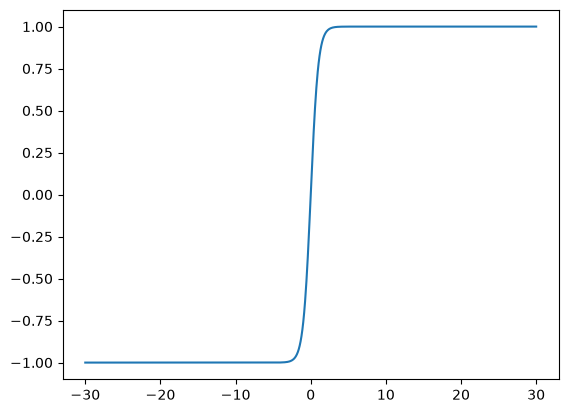

In [99]:
import matplotlib.pyplot as plt 
x = np.linspace(-30,30,1000)
y = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x)) # every value comes between -1 and 1 
plt.plot(x,y)

**Sigmoid Function**
**1/1 + e^(-x) for a given number x**

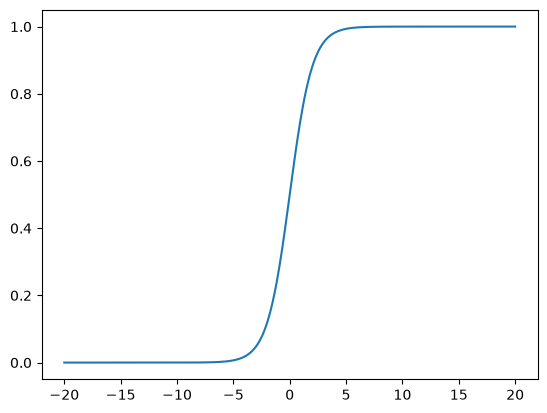

In [100]:
x =np.linspace(-20,20,500)
y = 1/ (1 + np.exp(-x)) # every value comes b/w 0 and 1 
plt.plot(x,y)

**Q-8: Plot the below equation.**

**y=sqroot ( 36−(x−4)^2 ) + 2**

The range of x should be between -2 to 10.  x∈[−2,10]

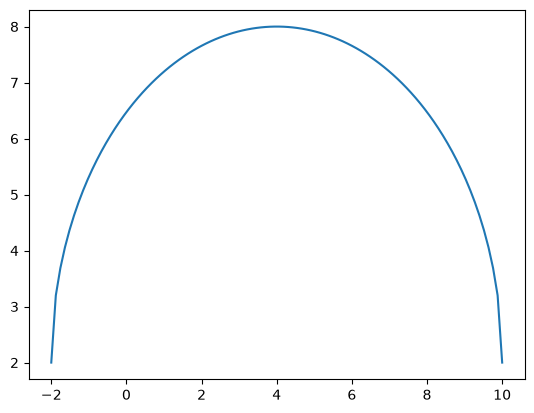

In [101]:
x = np.linspace(-2,10,100)
y = np.sqrt(36 - (x-4)**2) + 2
plt.plot(x,y)

In [122]:
def broadCasting(arr1 , arr2):
    if not isinstance(arr1 , np.ndarray) or not isinstance(arr2 , np.ndarray):
        raise TypeError("Only numpy arrays are allowed for broadcasting")

    shape1 =  arr1.shape
    shape2 =  arr2.shape
    if len(shape1) != len(shape2):
        smaller = shape1 if len(shape1) < len(shape2) else shape2
        larger = shape2  if smaller == shape1 else shape1
        while  len(smaller) != len(larger):
            smaller = (1,) + smaller
    if len(shape1) != len(shape2):
        shape1 = smaller
        shape2 = larger
    shape1 = np.array(shape1)
    shape2 = np.array(shape2)
    if np.any(shape1 == 1):
        indexs = np.where(shape1 == 1)
        shape1[indexs] = shape2[indexs]
    if np.any(shape2 == 1):
            indexs = np.where(shape2 == 1)
            shape2[indexs] = shape1[indexs]

    if np.all(shape1 == shape2):
         return True 
    return False 



In [123]:
# --- Tests ---

# Test 1: Impossible broadcast (2x2 and 2x3)
a = np.array([[1,2], [3,4]])
b = np.array([[1,2,3], [3,4,5]])

try:
    validation = broadCasting(a,b)
except TypeError as e:
    print(e)
else:
    print(validation)

# Test 2: Missing dimensions (3x4 and 4)
c = np.ones((3, 4))
d = np.ones((4,))

try:
    validation = broadCasting(c,d)
except TypeError as e:
    print(e)
else:
    print(validation)

# Test 3: Both have 1s in different places (3x1 and 1x4)
e = np.ones((3, 1))
f = np.ones((1, 4))

try:
    validation = broadCasting(e,f)
except TypeError as e:
    print(e)
else:
    print(validation)


False
True
True
